# Panorama des modèles IA : coût, compute, temps, données, énergie

Exploration globale des modèles IA (tous domaines) pour comparer compute, coûts, temps d'entraînement, taille de données et indicateurs d'énergie.
Sources : `../data/ai_models/all_ai_models.csv` et `../data/ai_models/notable_ai_models.csv`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)
root = Path('..') / 'data' / 'ai_models'

all_df = pd.read_csv(root / 'all_ai_models.csv')
notable_df = pd.read_csv(root / 'notable_ai_models.csv')

# Colonnes d'intérêt
num_cols = ['Parameters', 'Training compute (FLOP)', 'Training time (hours)',
            'Training compute cost (2023 USD)', 'Training dataset size (gradients)', 'Training power draw (W)']

for col in num_cols:
    if col in all_df.columns:
        all_df[col] = pd.to_numeric(all_df[col], errors='coerce')
    if col in notable_df.columns:
        notable_df[col] = pd.to_numeric(notable_df[col], errors='coerce')

# Assemblage priorisant notable pour champs énergie/coût
common_cols = list(set(all_df.columns) | set(notable_df.columns))
# On concat et garde les colonnes clés seulement
merged = pd.concat([all_df, notable_df], ignore_index=True, sort=False)
merged['Publication date'] = pd.to_datetime(merged.get('Publication date'), errors='coerce')
merged['Model accessibility'] = merged.get('Model accessibility').fillna('Unknown')
merged['Organization'] = merged.get('Organization').fillna('Unknown')
merged['Domain'] = merged.get('Domain').fillna('Unknown')

# Filtrer valeurs aberrantes (compute >1e27 FLOP considéré outlier pour lisibilité)
merged = merged[(merged['Training compute (FLOP)'].isna()) | (merged['Training compute (FLOP)'] < 1e27)]
merged.head()


,Model,Domain,Task,Organization,Authors,Publication date,Reference,Link,Citations,Notability criteria,...,Hugging Face developer id,Post-training compute (FLOP),Post-training compute notes,Hardware utilization (HFU),Training dataset,Compute cost notes,Inference code accessibility,Hardware acquisition cost,Training compute cost (cloud),Training compute cost (upfront)
0,Claude Opus 4.5,"Language,Multimodal,Vision","Code generation,Language modeling/generation,Q...",Anthropic,NaN,2025-11-24,Introducing Claude Opus 4.5,https://www.anthropic.com/news/claude-opus-4-5,NaN,SOTA improvement,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Gemini 3 Pro,"Multimodal,Language,Vision",Language modeling/generation,Google DeepMind,NaN,2025-11-18,A new era of intelligence with Gemini 3,https://blog.google/products/gemini/gemini-3/,NaN,Significant use,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,GPT-5.1,"Multimodal,Language,Vision","Language modeling/generation,Question answering",OpenAI,NaN,2025-11-13,"GPT-5.1: A smarter, more conversational ChatGPT",https://openai.com/index/gpt-5-1/,NaN,Significant use,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Kimi K2 Thinking,Language,"Language modeling/generation,Question answerin...",Moonshot,NaN,2025-11-06,Introducing Kimi K2 Thinking,https://moonshotai.github.io/Kimi-K2/thinking,NaN,SOTA improvement,...,moonshotai,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Gen-0,Robotics,Robotic manipulation,Generalist,NaN,2025-11-04,GEN-0 / Embodied Foundation Models That Scale ...,https://generalistai.com/blog/nov-04-2025-GEN-0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [2]:
# Statistiques globales par accessibilité (open/closed/unknown)
access_stats = merged.groupby('Model accessibility')[['Parameters','Training compute (FLOP)','Training time (hours)','Training compute cost (2023 USD)']].median().reset_index()
access_stats

,Model accessibility,Parameters,Training compute (FLOP),Training time (hours),Training compute cost (2023 USD)
0,API access,2.400000e+10,1.388556e+24,2016.00,5.014267e+06
1,Hosted access (no API),3.300000e+10,2.000000e+23,276.00,4.417700e+05
2,Open weights (non-commercial),6.700000e+09,8.743950e+21,205.75,5.117186e+04
3,Open weights (restricted use),1.300000e+10,3.656640e+23,290.00,2.373335e+05
4,Open weights (unrestricted),3.100000e+09,8.955000e+21,234.00,7.340099e+03
5,Unknown,4.718592e+07,1.277338e+17,60.00,4.281742e+02
6,Unreleased,2.130000e+08,4.456180e+19,120.00,5.165971e+04


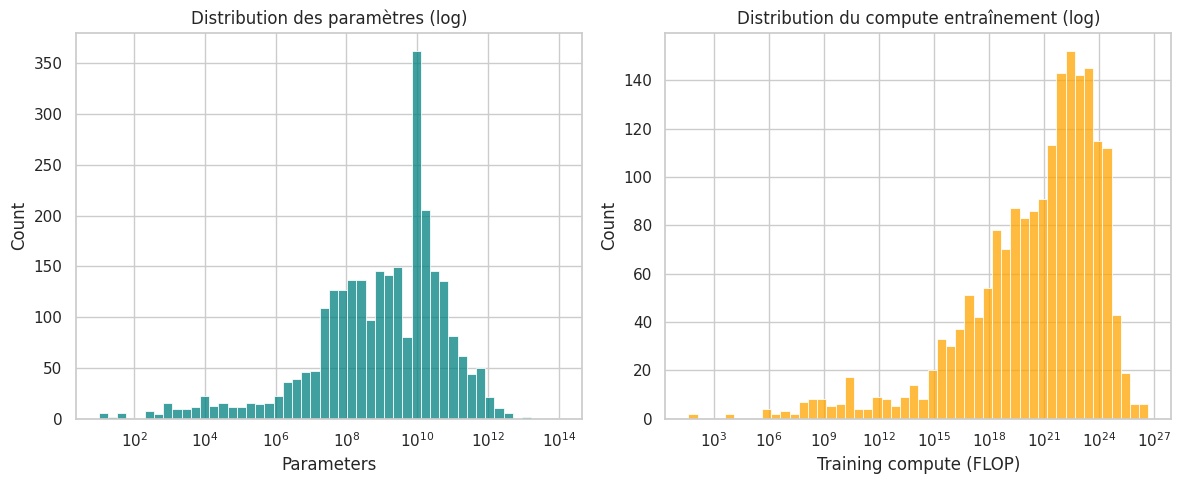

In [3]:
# Distribution paramètres et compute
fig, axes = plt.subplots(1,2, figsize=(12,5))
sns.histplot(merged['Parameters'].dropna(), bins=50, log_scale=True, ax=axes[0], color='teal')
axes[0].set_title('Distribution des paramètres (log)')
sns.histplot(merged['Training compute (FLOP)'].dropna(), bins=50, log_scale=True, ax=axes[1], color='orange')
axes[1].set_title('Distribution du compute entraînement (log)')
plt.tight_layout(); plt.show()


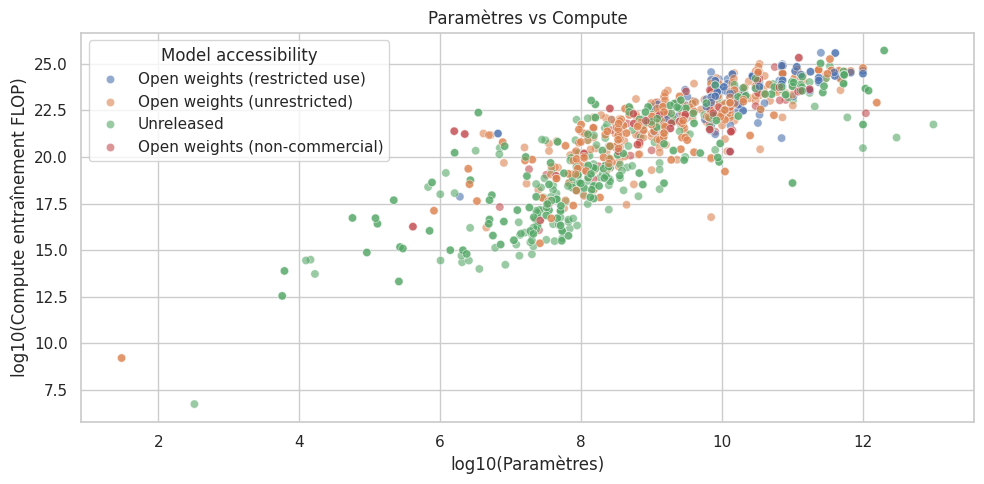

In [9]:
# Relation paramètres vs compute (log-log)
subset = merged.dropna(subset=['Parameters','Training compute (FLOP)'])
# Filtrer pour garder uniquement open weights et unreleased
subset = subset[subset['Model accessibility'].str.contains('Open weights|Unreleased', na=False, case=False)]
subset['log_params'] = np.log10(subset['Parameters'])
subset['log_compute'] = np.log10(subset['Training compute (FLOP)'])
ax = sns.scatterplot(data=subset, x='log_params', y='log_compute', hue=subset['Model accessibility'], alpha=0.6)
ax.set_xlabel('log10(Paramètres)')
ax.set_ylabel('log10(Compute entraînement FLOP)')
ax.set_title('Paramètres vs Compute')
plt.tight_layout(); plt.show()


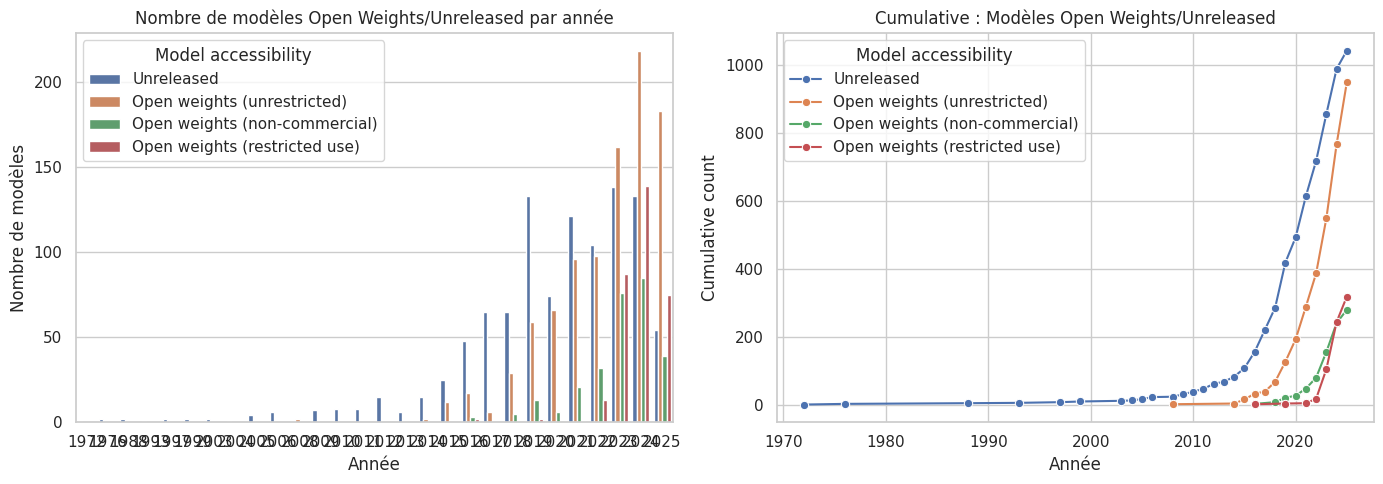

In [11]:
# Evolution d'apparaition des modèles open weights et unreleased dans le temps
# Evolution d'apparition des modèles open weights et unreleased dans le temps
time_subset = merged.dropna(subset=['Publication date'])
time_subset = time_subset[time_subset['Model accessibility'].str.contains('Open weights|Unreleased', na=False, case=False)]
time_subset['year'] = time_subset['Publication date'].dt.year

# Compter les modèles par année et type d'accessibilité
yearly_counts = time_subset.groupby(['year', 'Model accessibility']).size().reset_index(name='count')

# Cumulative count
yearly_counts = yearly_counts.sort_values(['year', 'Model accessibility'])
yearly_counts['Cumulative count'] = yearly_counts.groupby('Model accessibility')['count'].cumsum()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Comptage annuel
sns.barplot(data=yearly_counts, x='year', y='count', hue='Model accessibility', ax=axes[0])
axes[0].set_title('Nombre de modèles Open Weights/Unreleased par année')
axes[0].set_xlabel('Année')
axes[0].set_ylabel('Nombre de modèles')

# Graphique 2 : Cumulative
sns.lineplot(data=yearly_counts, x='year', y='Cumulative count', hue='Model accessibility', marker='o', ax=axes[1])
axes[1].set_title('Cumulative : Modèles Open Weights/Unreleased')
axes[1].set_xlabel('Année')
axes[1].set_ylabel('Cumulative count')

plt.tight_layout(); plt.show()


/tmp/ipykernel_59833/1224929882.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['compute_per_param'] = subset['Training compute (FLOP)'] / subset['Parameters']


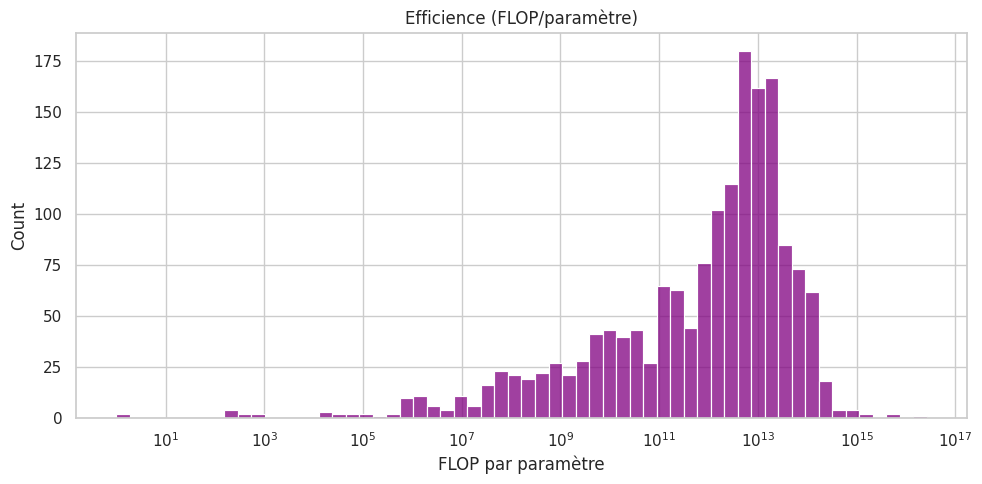

In [5]:
# Efficience algorithme : FLOP par paramètre
subset['compute_per_param'] = subset['Training compute (FLOP)'] / subset['Parameters']
ax = sns.histplot(subset['compute_per_param'].dropna(), bins=60, log_scale=True, color='purple')
ax.set_xlabel('FLOP par paramètre')
ax.set_title('Efficience (FLOP/paramètre)')
plt.tight_layout(); plt.show()


/tmp/ipykernel_59833/1624124261.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_time['log_compute'] = np.log10(subset_time['Training compute (FLOP)'])
/tmp/ipykernel_59833/1624124261.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_time['log_time'] = np.log10(subset_time['Training time (hours)'])
/tmp/ipykernel_59833/1624124261.py:9: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(); pl

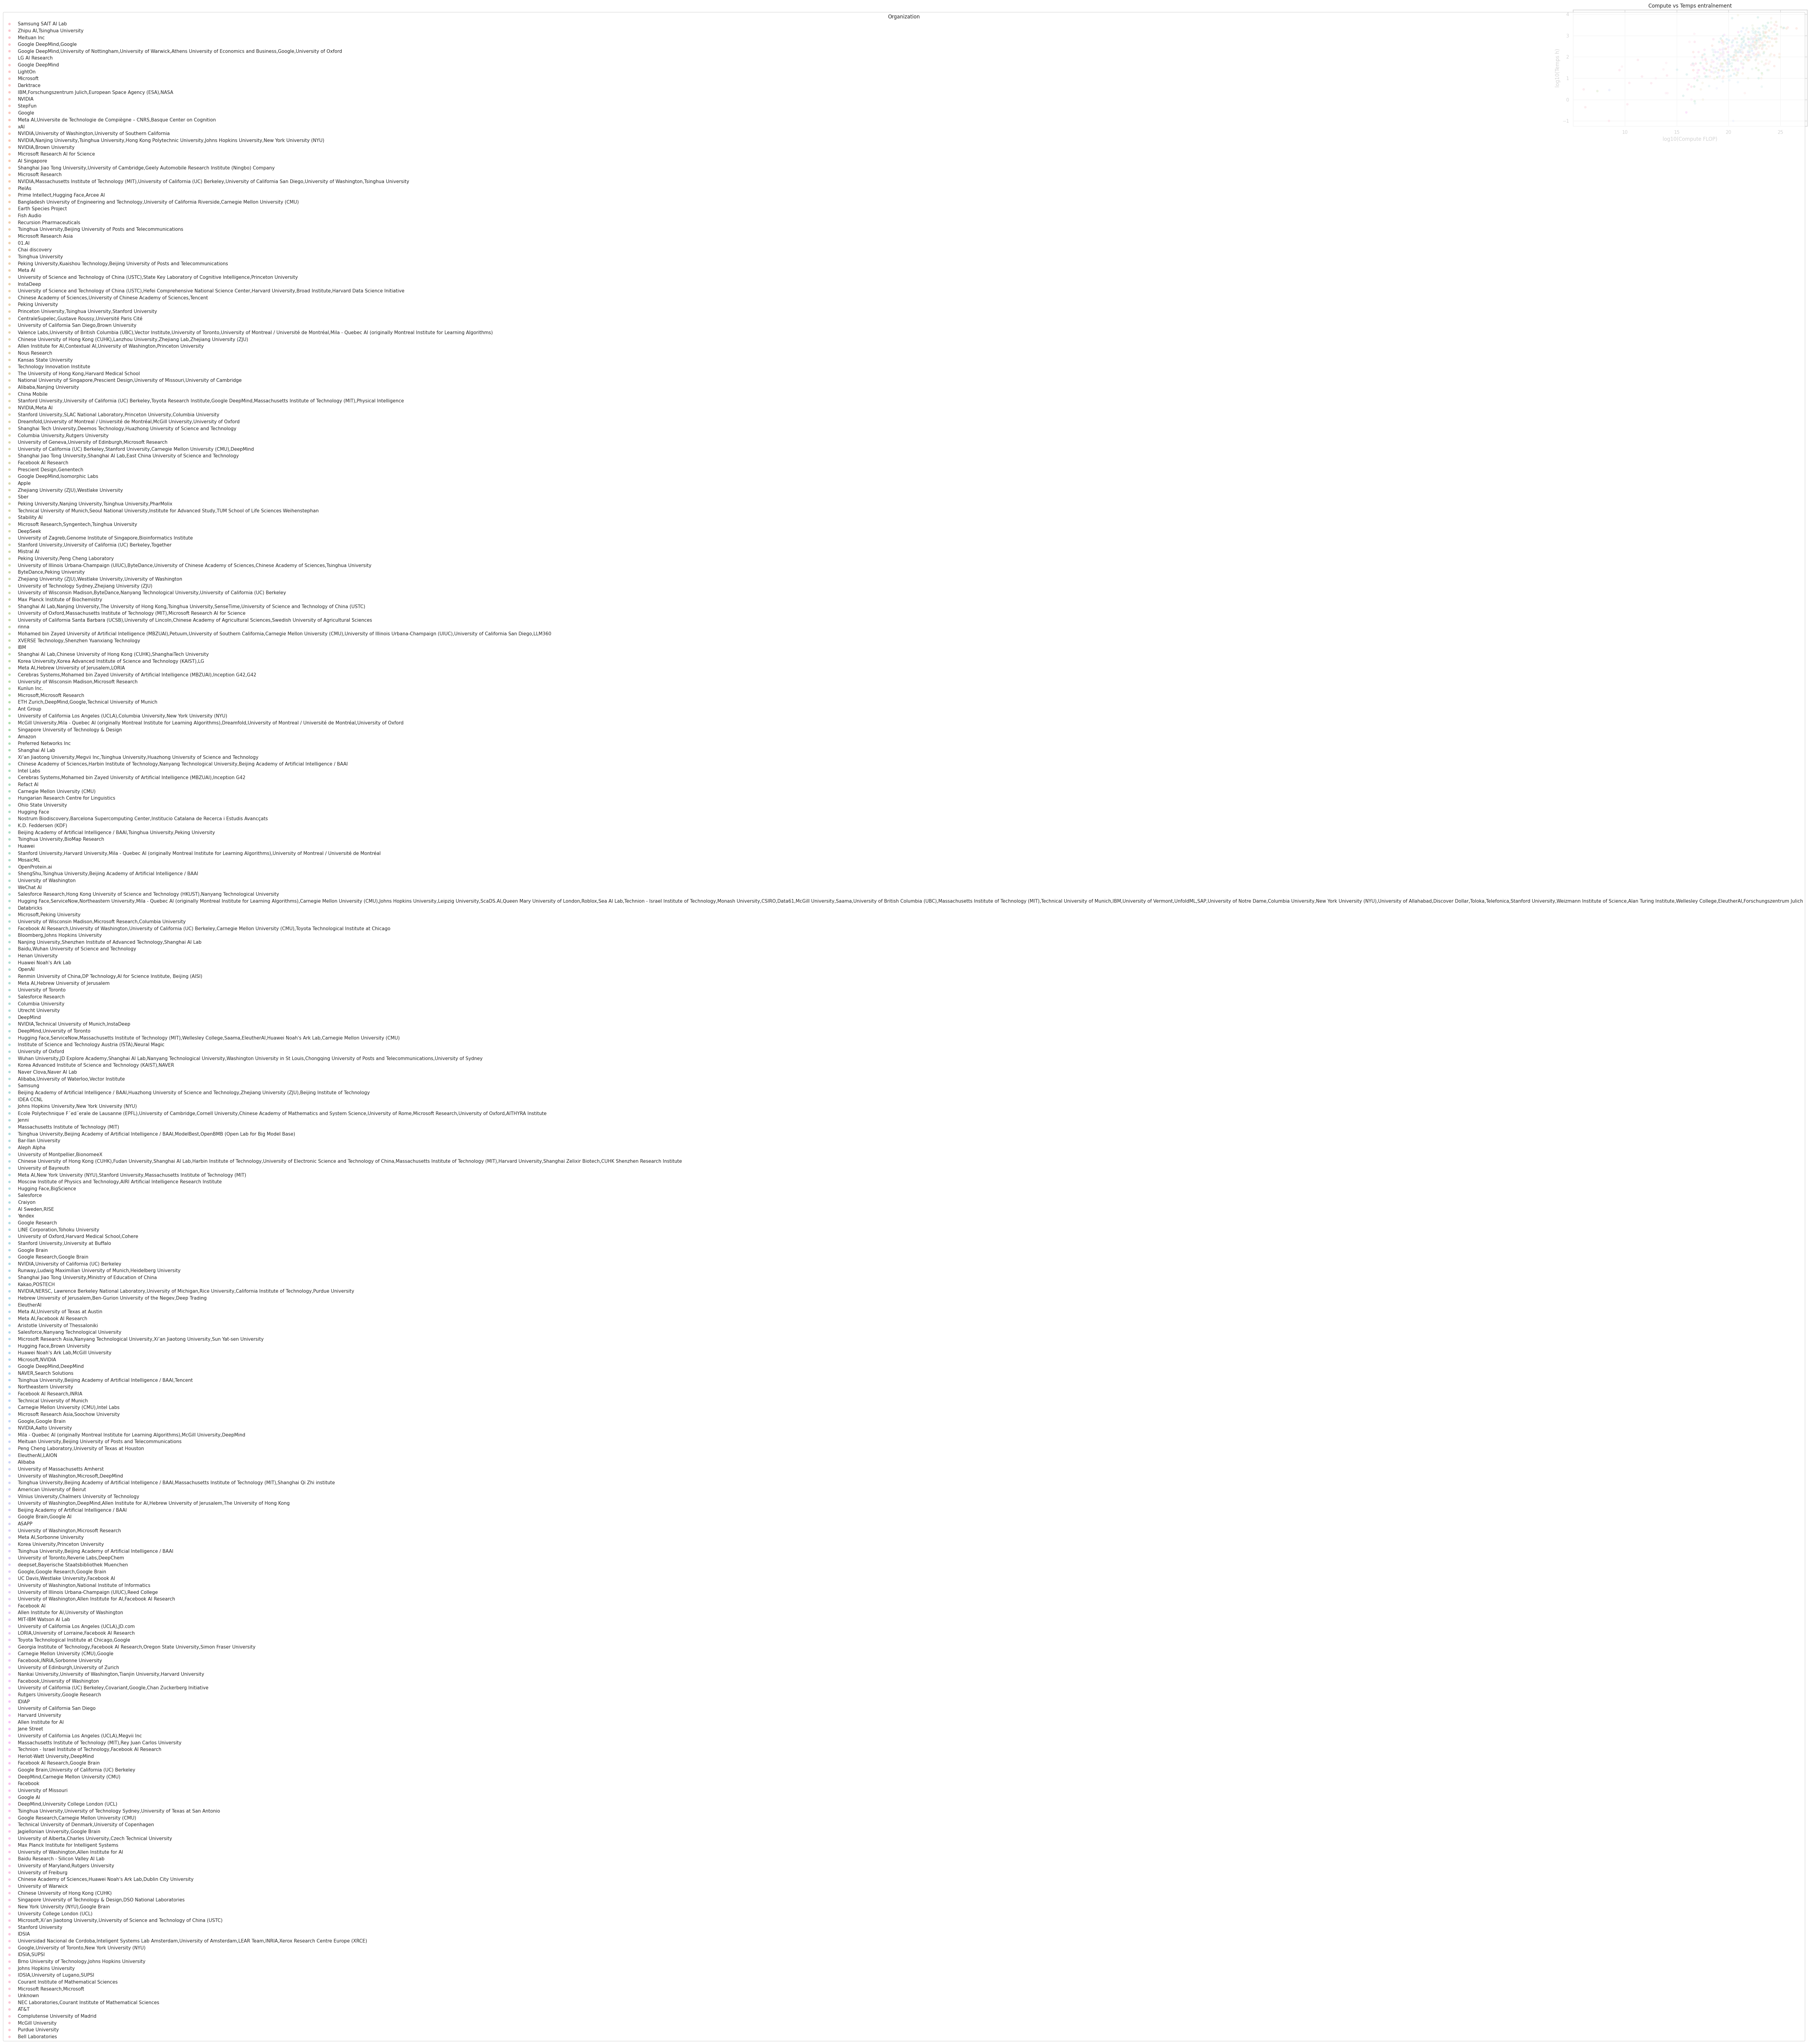

In [6]:
# Temps vs compute : efficience infra (heures pour un volume de compute)
subset_time = merged.dropna(subset=['Training compute (FLOP)','Training time (hours)'])
subset_time['log_compute'] = np.log10(subset_time['Training compute (FLOP)'])
subset_time['log_time'] = np.log10(subset_time['Training time (hours)'])
ax = sns.scatterplot(data=subset_time, x='log_compute', y='log_time', hue=subset_time['Organization'], alpha=0.4)
ax.set_xlabel('log10(Compute FLOP)')
ax.set_ylabel('log10(Temps h)')
ax.set_title('Compute vs Temps entraînement')
plt.tight_layout(); plt.show()


/tmp/ipykernel_59833/4042223346.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset_cost['cost_per_flop'] = subset_cost['Training compute cost (2023 USD)'] / subset_cost['Training compute (FLOP)']


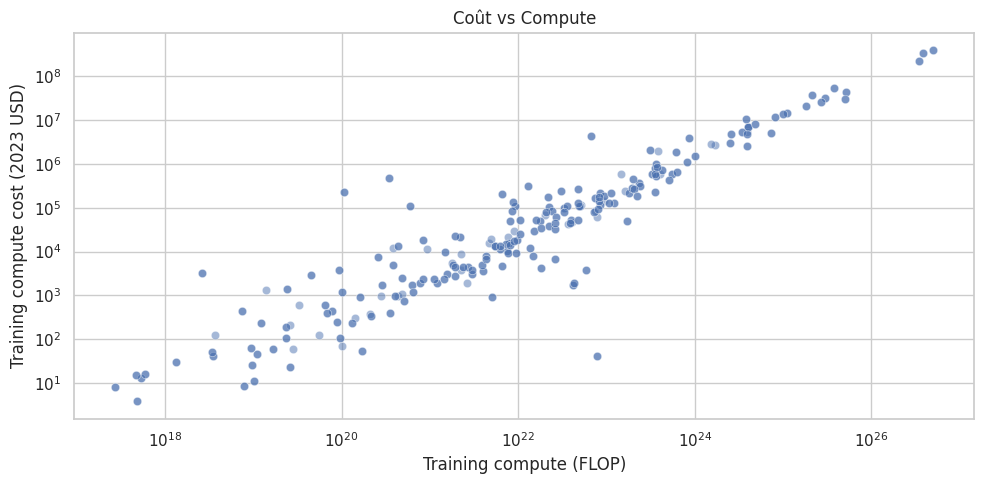

In [7]:
# Coût vs compute (quand disponible)
subset_cost = merged.dropna(subset=['Training compute (FLOP)','Training compute cost (2023 USD)'])
subset_cost['cost_per_flop'] = subset_cost['Training compute cost (2023 USD)'] / subset_cost['Training compute (FLOP)']
ax = sns.scatterplot(data=subset_cost, x='Training compute (FLOP)', y='Training compute cost (2023 USD)', alpha=0.5)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_title('Coût vs Compute')
plt.tight_layout(); plt.show()


/tmp/ipykernel_59833/3148104612.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ann['year'] = ann['Publication date'].dt.year


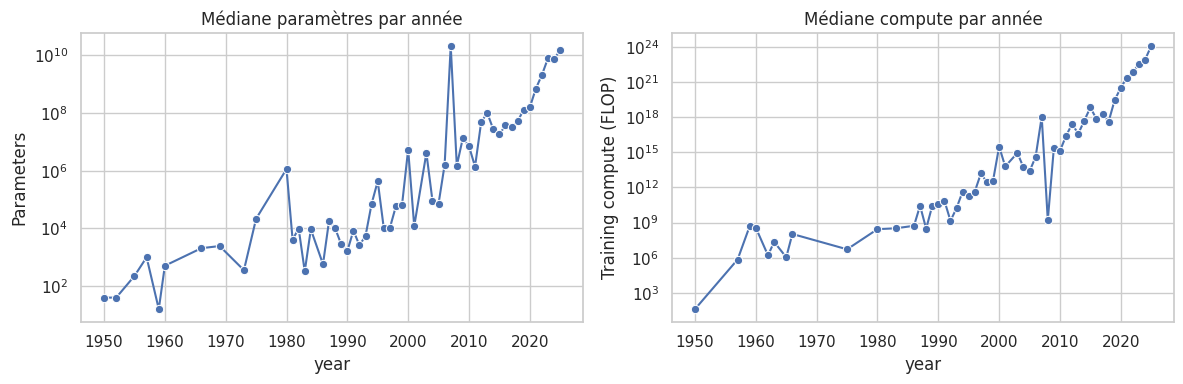

In [8]:
# Évolution temporelle du compute/paramètres (médiane annuelle)
ann = merged.dropna(subset=['Publication date'])
ann['year'] = ann['Publication date'].dt.year
ann_stats = ann.groupby('year')[['Parameters','Training compute (FLOP)']].median().reset_index()
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.lineplot(data=ann_stats, x='year', y='Parameters', marker='o', ax=axes[0])
axes[0].set_yscale('log'); axes[0].set_title('Médiane paramètres par année')
sns.lineplot(data=ann_stats, x='year', y='Training compute (FLOP)', marker='o', ax=axes[1])
axes[1].set_yscale('log'); axes[1].set_title('Médiane compute par année')
plt.tight_layout(); plt.show()


## Lecture rapide
- Distributions très étalées (plusieurs ordres de grandeur) pour paramètres et compute.
- La relation params→compute est super-linéaire : les gros modèles exigent des volumes de compute disproportionnés.
- Le coût vs compute est fortement corrélé mais peu renseigné : les points disponibles montrent des coûts qui explosent avec le compute.
- Les médianes annuelles progressent rapidement, illustrant la pression sur l’énergie et les coûts.
- Les ratios FLOP/paramètre varient, signe d’optimisations algorithmiques ou de stratégies de données.
